In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


LOAD DATASET

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


DATA PREPROCESSING

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [ ]:
print(df.isnull())


      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0          False   False          False    False       False   False   
1          False   False          False    False       False   False   
2          False   False          False    False       False   False   
3          False   False          False    False       False   False   
4          False   False          False    False       False   False   
...          ...     ...            ...      ...         ...     ...   
7038       False   False          False    False       False   False   
7039       False   False          False    False       False   False   
7040       False   False          False    False       False   False   
7041       False   False          False    False       False   False   
7042       False   False          False    False       False   False   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0            False          False            False          

In [ ]:
df.dropna(axis=0, how='any', inplace=True)


In [ ]:
df.shape

(7032, 21)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,0


ENCODER

In [ ]:
le = LabelEncoder()
for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

le

LabelEncoder()

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

SCALING

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

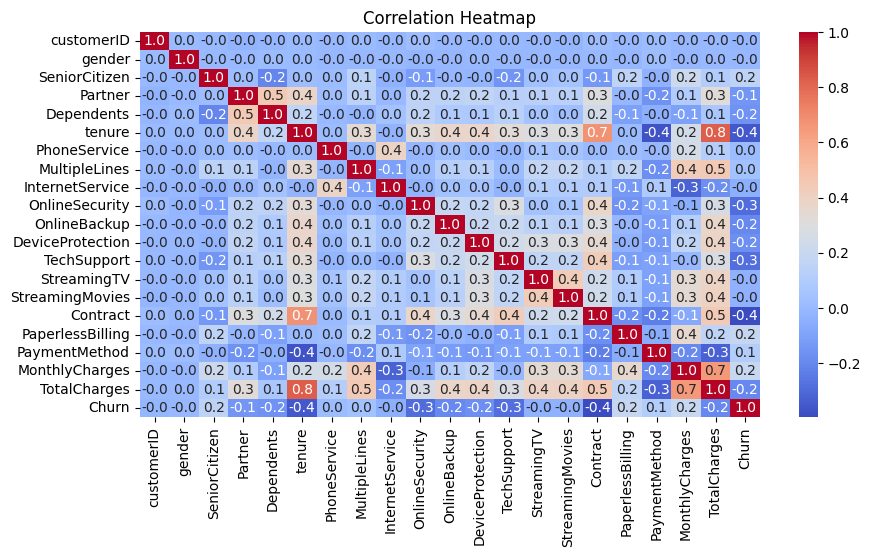

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(), annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

SALES TREND ANALYSIS

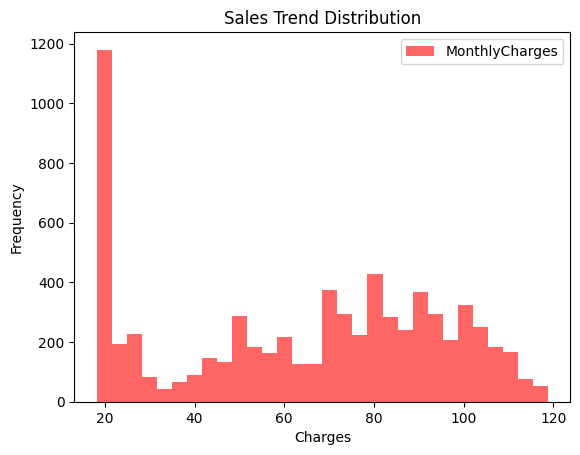

In [ ]:
df['MonthlyCharges'].plot(kind='hist',color='red', bins=30, alpha=0.6, label='MonthlyCharges')
plt.legend()
plt.title('Sales Trend Distribution')
plt.xlabel('Charges')
plt.show()

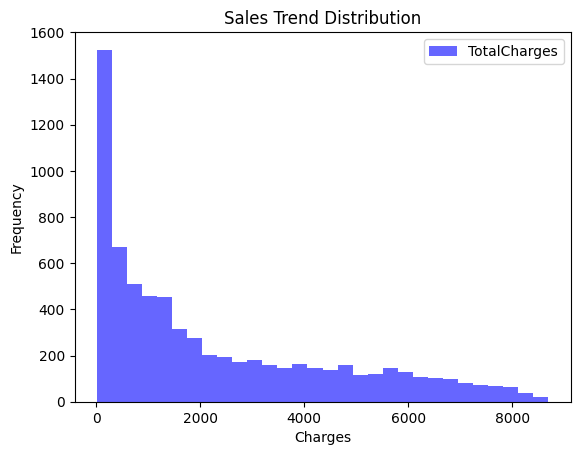

In [ ]:
df['TotalCharges'].plot(kind='hist',color='blue', bins=30, alpha=0.6, label='TotalCharges')
plt.legend()
plt.title('Sales Trend Distribution')
plt.xlabel('Charges')
plt.show()

SPLIT DATA

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


TRAIN MODEL

Logistic Regression:
Accuracy: 0.7867803837953091
Precision: 0.625
Recall: 0.4946524064171123
F1 Score: 0.5522388059701493
ROC AUC: 0.8300133042744512


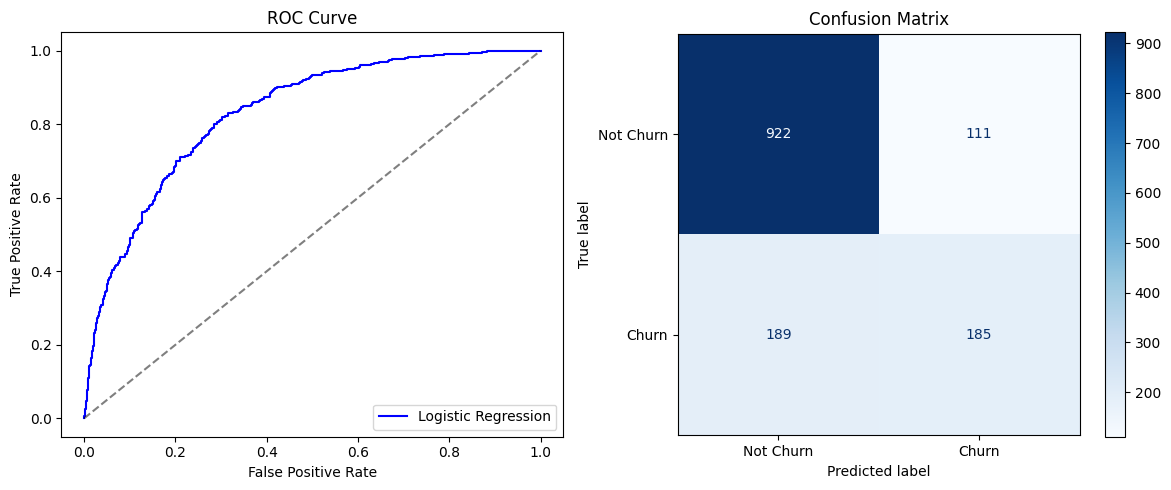

In [ ]:
# Logistic Regression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:",  precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))


fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

# subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label="Logistic Regression", color='blue')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)  # Diagonal reference
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc='lower right')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not Churn', 'Churn'])
disp.plot(ax=axes[1], values_format='d', cmap='Blues')
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()


Random Forest:
Accuracy: 0.7903340440653873
Precision: 0.6436363636363637
Recall: 0.4732620320855615
F1 Score: 0.5454545454545454
ROC AUC: 0.8206032478995293


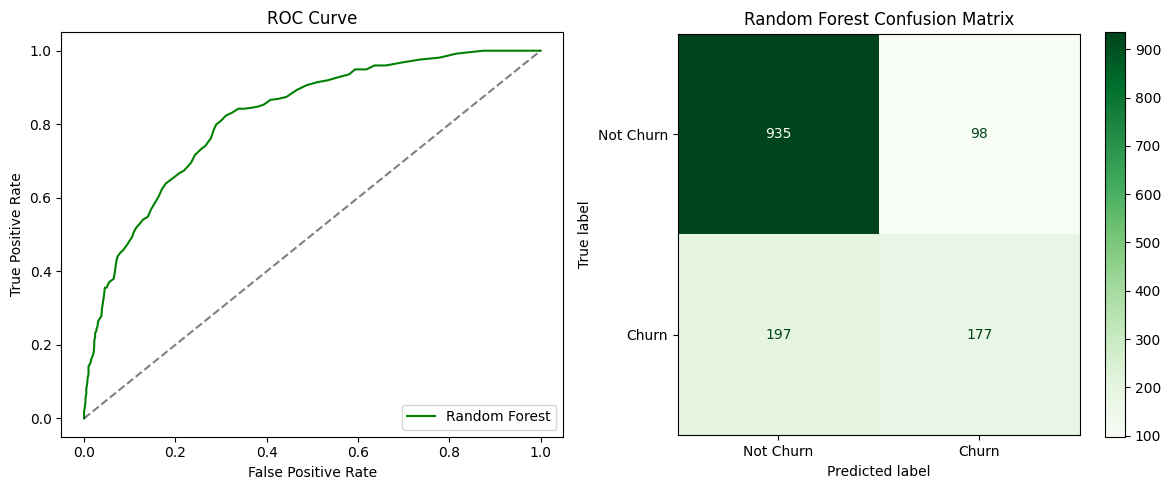

In [ ]:
#Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))


fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)

# subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label="Random Forest", color='green')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc='lower right')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not Churn', 'Churn'])
disp.plot(ax=axes[1], values_format='d', cmap='Greens')
axes[1].set_title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()


Decision Tree:
Accuracy: 0.7299218194740583
Precision: 0.4923469387755102
Recall: 0.516042780748663
F1 Score: 0.5039164490861618
ROC AUC: 0.6616999963762676


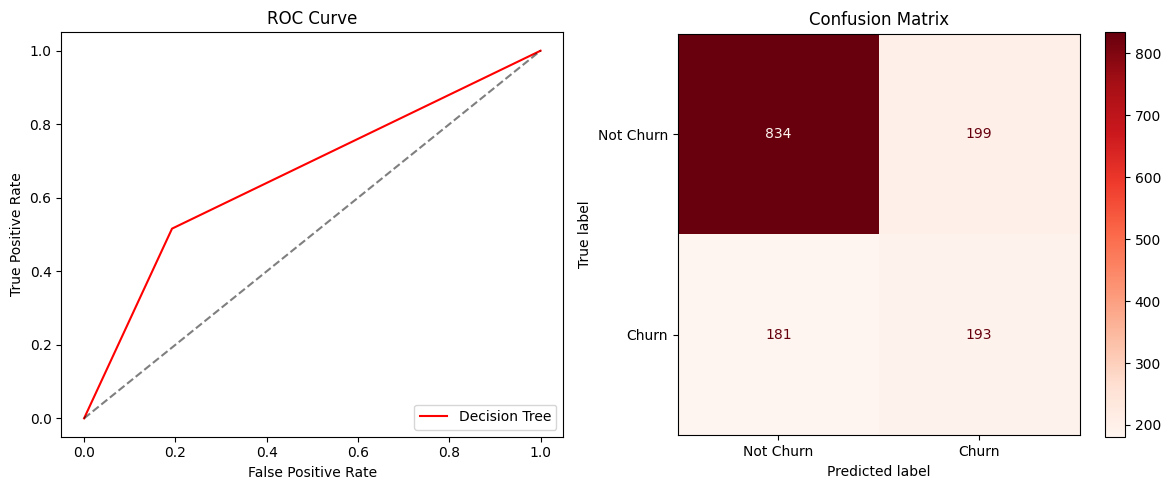

In [ ]:
# DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, y_proba_dt))

fpr, tpr, _ = roc_curve(y_test, y_proba_dt)

cm_dt = confusion_matrix(y_test, y_pred_dt)

# subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label="Decision Tree", color='red')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc='lower right')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Not Churn', 'Churn'])
disp.plot(ax=axes[1], values_format='d', cmap='Reds')
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()


KNN:
Accuracy: 0.7398720682302772
Precision: 0.510989010989011
Recall: 0.49732620320855614
F1 Score: 0.5040650406504065
ROC AUC: 0.7558251497377971


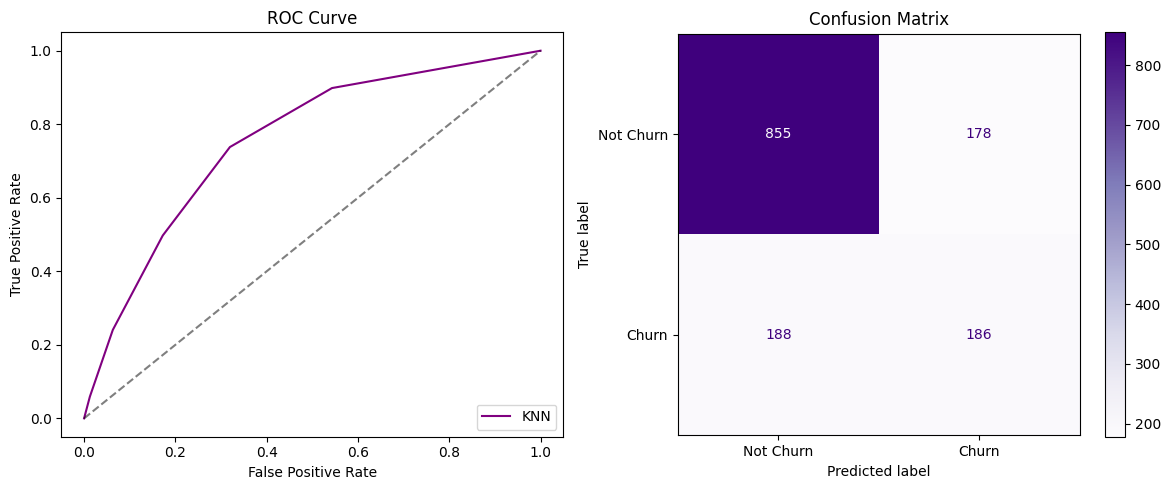

In [ ]:
#knn
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

print("KNN:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC AUC:", roc_auc_score(y_test, y_proba_knn))


fpr, tpr, _ = roc_curve(y_test, y_proba_knn)

cm_knn = confusion_matrix(y_test, y_pred_knn)

# subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label="KNN", color='purple')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc='lower right')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Not Churn', 'Churn'])
disp.plot(ax=axes[1], values_format='d', cmap='Purples')
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()


SVM:
Accuracy: 0.7924662402274343
Precision: 0.6541353383458647
Recall: 0.46524064171123
F1 Score: 0.54375
ROC AUC: 0.7762798246113547


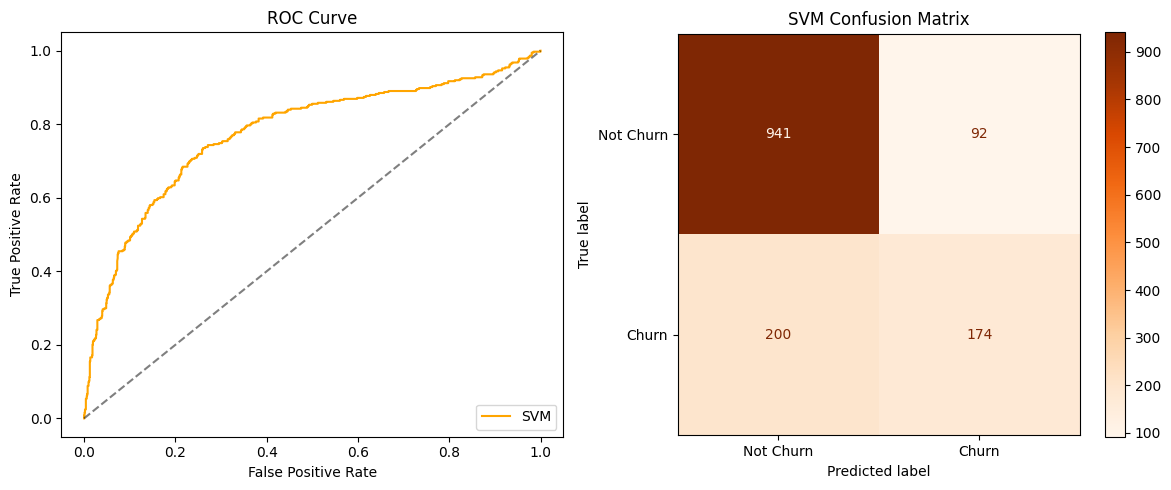

In [ ]:
# SVM

svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:, 1]

print("SVM:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC AUC:", roc_auc_score(y_test, y_proba_svm))

fpr, tpr, _ = roc_curve(y_test, y_proba_svm)

cm_svm = confusion_matrix(y_test, y_pred_svm)

# subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label="SVM", color='orange')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc='lower right')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Not Churn', 'Churn'])
disp.plot(ax=axes[1], values_format='d', cmap='Oranges')
axes[1].set_title("SVM Confusion Matrix")

plt.tight_layout()
plt.show()

Naive Bayes:
Accuracy: 0.7398720682302772
Precision: 0.5074074074074074
Recall: 0.732620320855615
F1 Score: 0.5995623632385121
ROC AUC: 0.8124847932660699


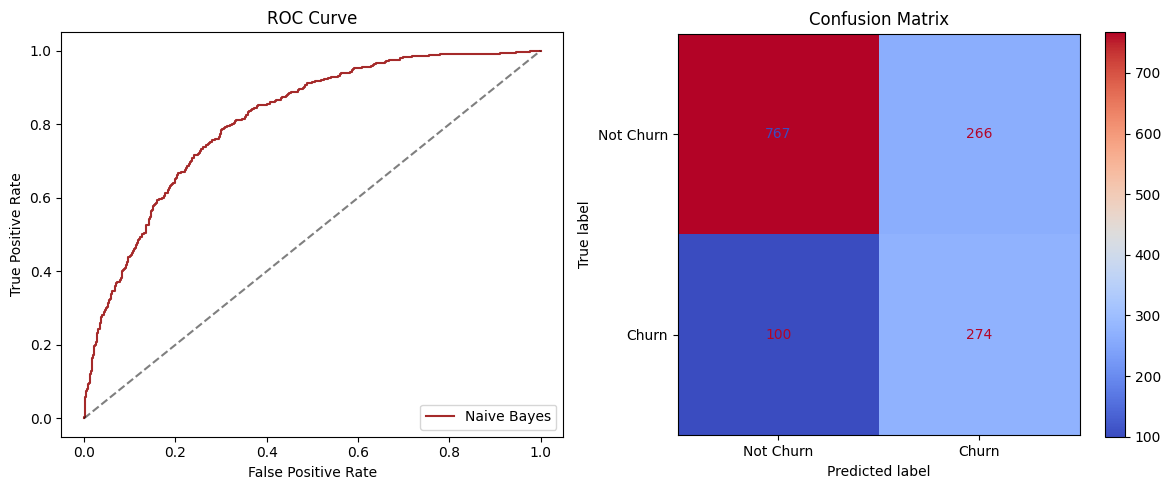

In [ ]:
#NAIVE BAYES

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_proba_nb = nb.predict_proba(X_test)[:, 1]

print("Naive Bayes:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_nb))

fpr, tpr, _ = roc_curve(y_test, y_proba_nb)

cm_nb = confusion_matrix(y_test, y_pred_nb)

# subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label="Naive Bayes", color='brown')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc='lower right')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Not Churn', 'Churn'])
disp.plot(ax=axes[1], values_format='d', cmap='coolwarm')
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()


XGBoost:
Accuracy: 0.7796730632551528
Precision: 0.6081081081081081
Recall: 0.48128342245989303
F1 Score: 0.5373134328358209
ROC AUC: 0.809710049645133


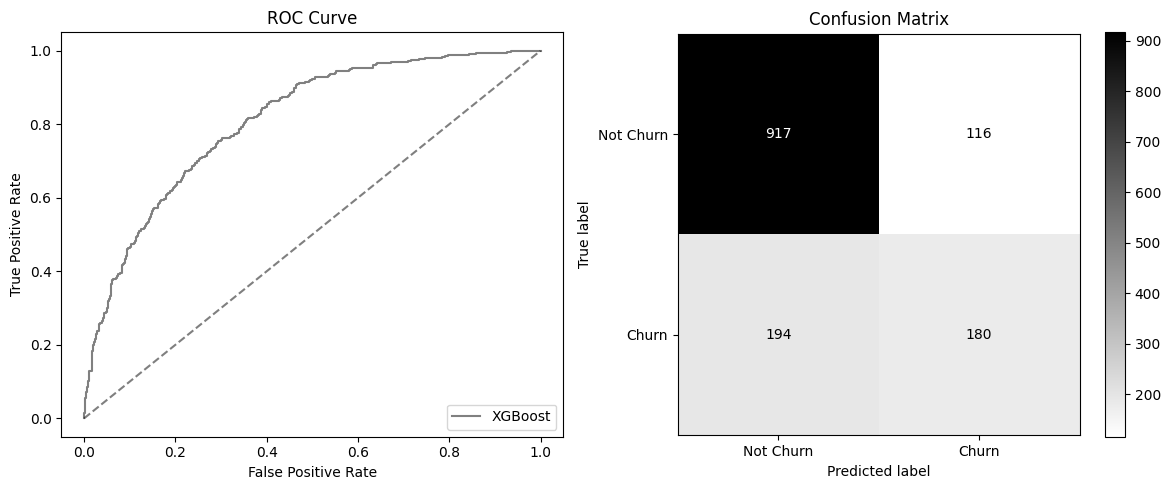

In [ ]:
# XGBOOST

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBoost:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label="XGBoost", color='gray')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc='lower right')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Not Churn', 'Churn'])
disp.plot(ax=axes[1], values_format='d', cmap='gray_r')
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()


LightGBM:
Accuracy: 0.7910447761194029
Precision: 0.636986301369863
Recall: 0.49732620320855614
F1 Score: 0.5585585585585585
ROC AUC: 0.8210419783507876


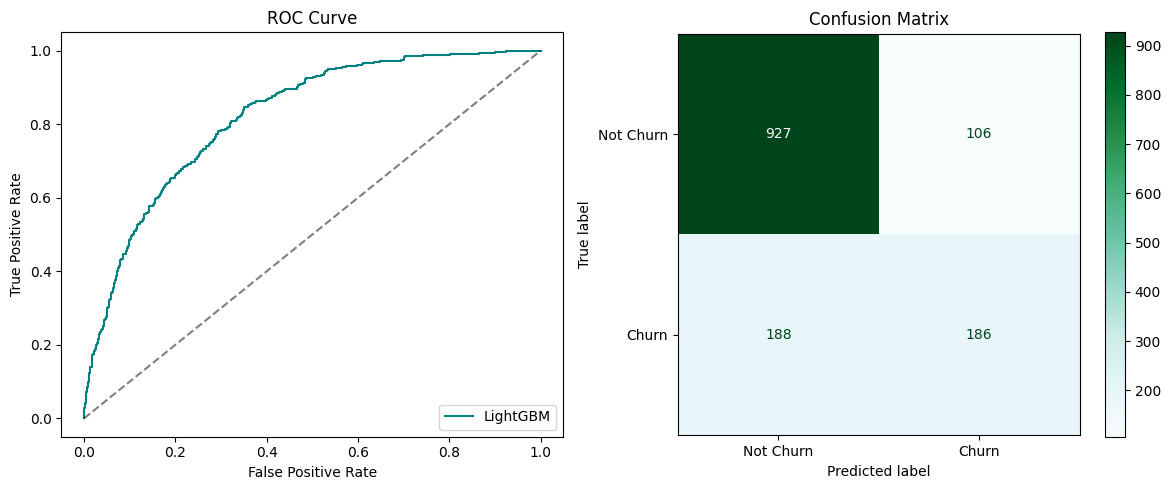

In [ ]:
# LightGBM

lgbm = LGBMClassifier(verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("LightGBM:")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall:", recall_score(y_test, y_pred_lgbm))
print("F1 Score:", f1_score(y_test, y_pred_lgbm))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lgbm))

fpr, tpr, _ = roc_curve(y_test, y_proba_lgbm)

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

# subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label="LightGBM", color='teal')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc='lower right')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm, display_labels=['Not Churn', 'Churn'])
disp.plot(ax=axes[1], values_format='d', cmap='BuGn')
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()




KMeans Cluster vs Actual Churn Cross Tab:
Churn              0     1
KMeans_Cluster            
0               2337   371
1               2826  1498


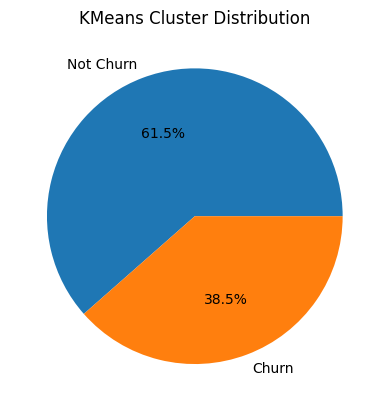

In [ ]:
# K Means
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels


print("\nKMeans Cluster vs Actual Churn Cross Tab:")
print(pd.crosstab(df['KMeans_Cluster'], df['Churn']))

churn_counts = df.groupby('KMeans_Cluster')['Churn'].value_counts(normalize=True).unstack()

if churn_counts.loc[0, 1] > churn_counts.loc[1, 1]:
    pie_labels = ['Churn', 'Not Churn']
else:
    pie_labels = ['Not Churn', 'Churn']

plt.pie(df['KMeans_Cluster'].value_counts(), labels=pie_labels, autopct='%1.1f%%')
plt.title('KMeans Cluster Distribution')
plt.show()

MODEL EVALUATION

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.786780,0.625000,0.494652,0.552239,0.830013
1,Random Forest,0.790334,0.643636,0.473262,0.545455,0.819882
2,Decision Tree,0.729922,0.492424,0.521390,0.506494,0.663406
3,KNN,0.739872,0.510989,0.497326,0.504065,0.755825
4,SVM,0.792466,0.654135,0.465241,0.543750,0.776273
5,Naive Bayes,0.739872,0.507407,0.732620,0.599562,0.812485
6,XGBoost,0.779673,0.608108,0.481283,0.537313,0.809710
7,LightGBM,0.791045,0.636986,0.497326,0.558559,0.821042


MODEL EVALUATION VISUALIZATION

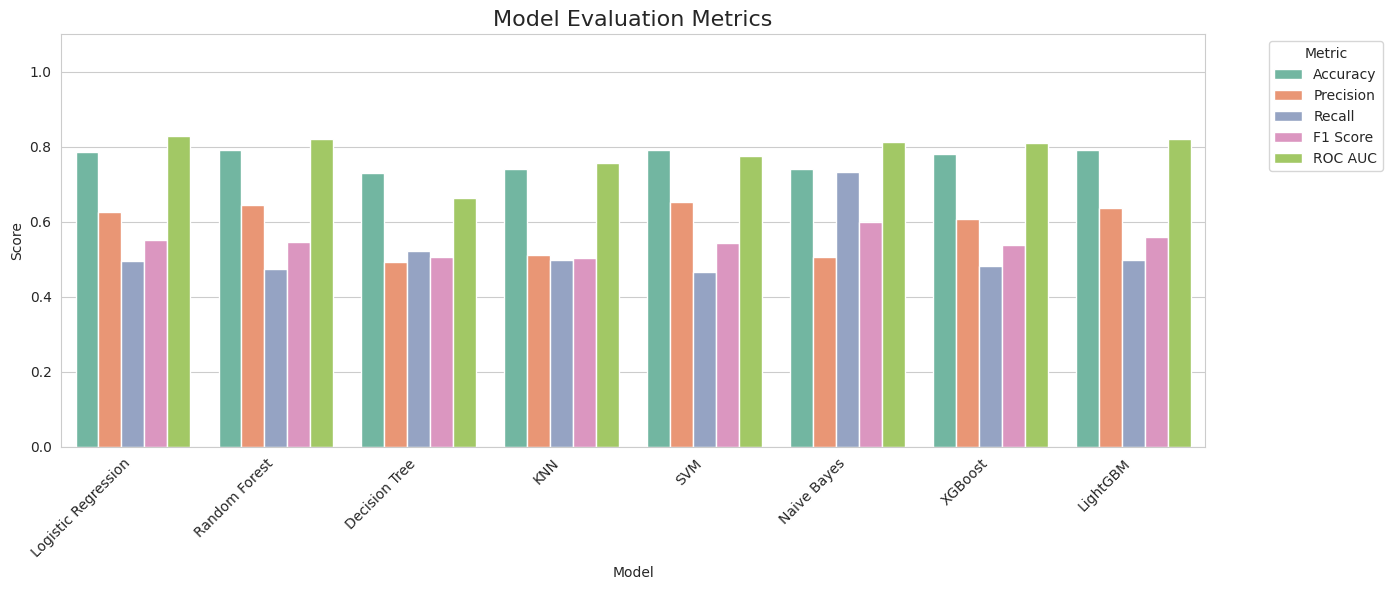

In [ ]:
metrics_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

sns.barplot(data=metrics_df, x="Model", y="Score", hue="Metric", palette="Set2")

plt.title("Model Evaluation Metrics", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Score")
plt.ylim(0, 1.1)  # Scores range from 0 to 1
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


VISUALIZATION OF FACTORS RELEVENT TO CHURN

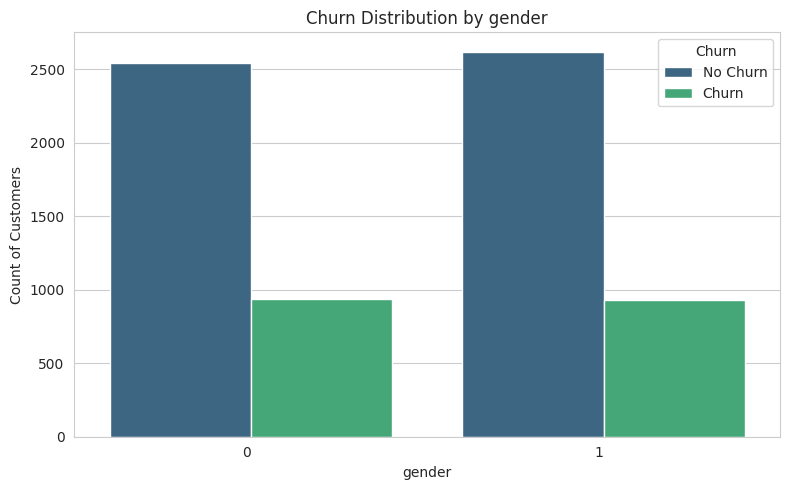

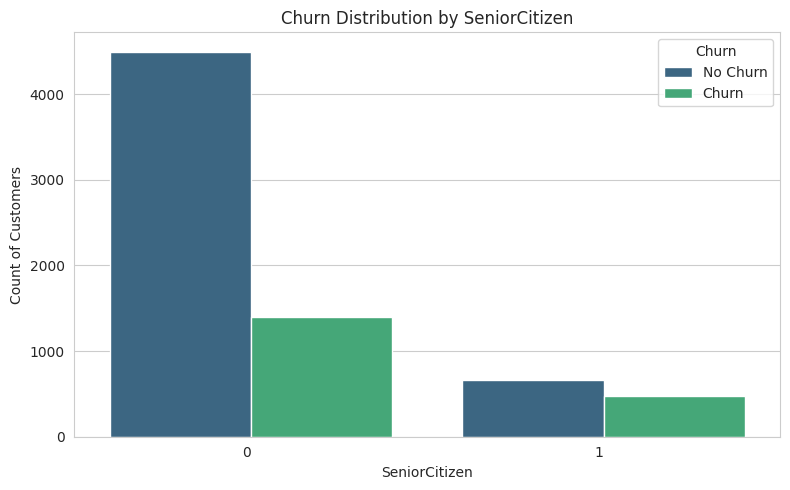

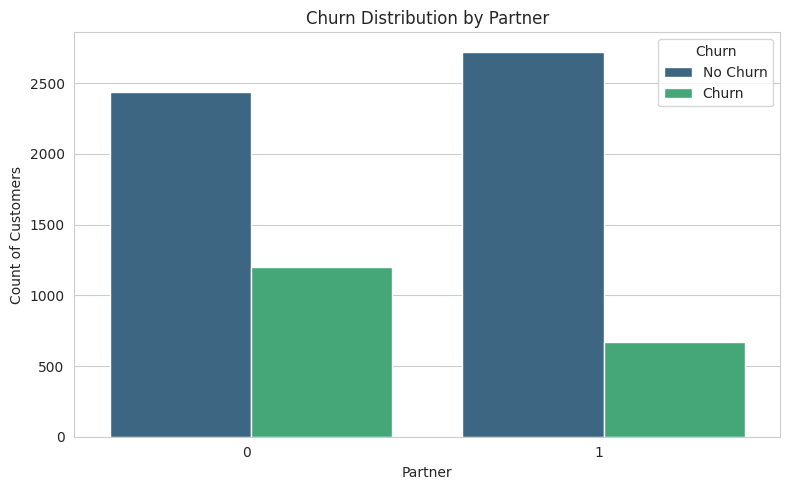

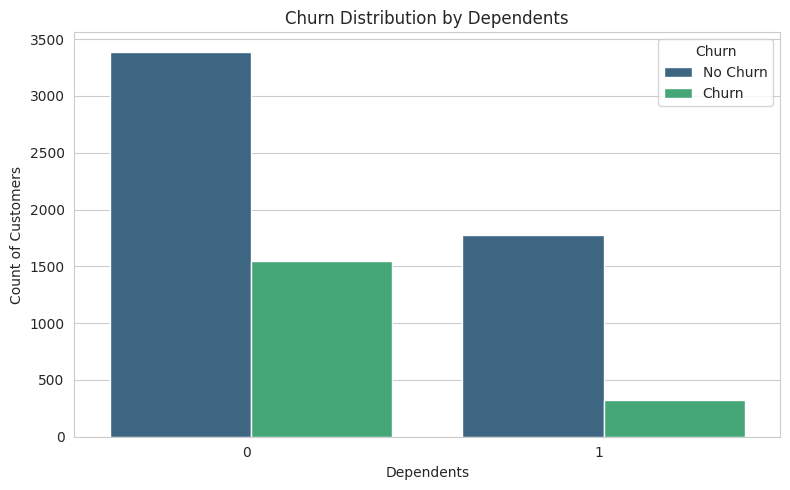

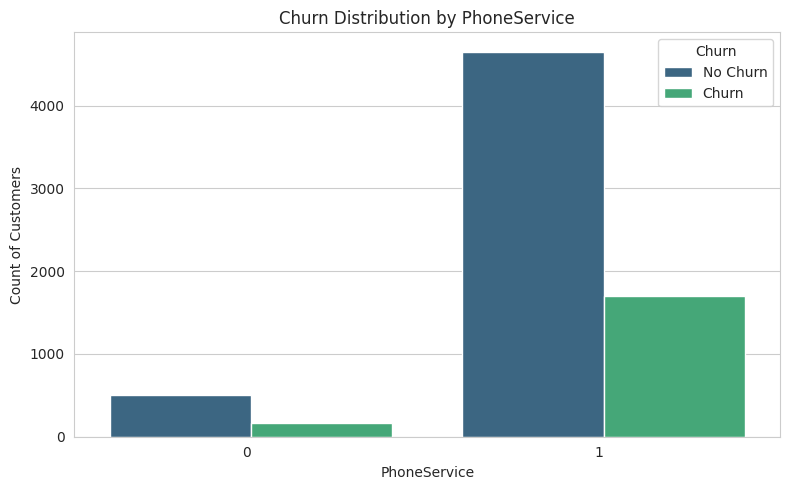

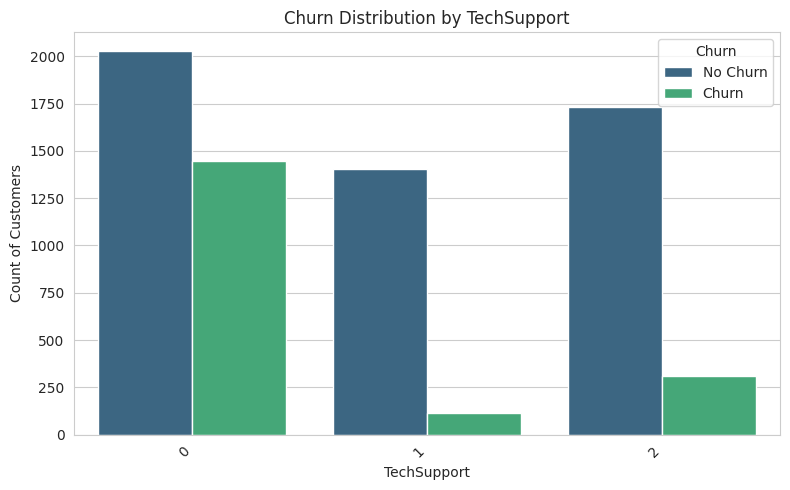

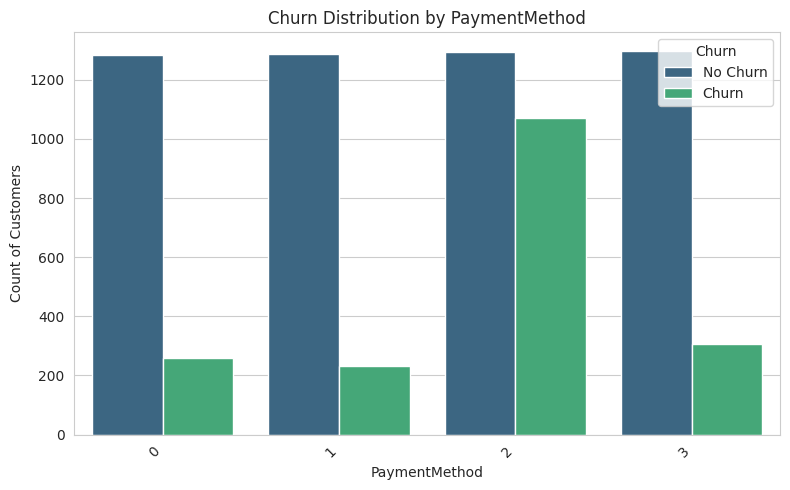

In [ ]:
columns_to_plot = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                   'TechSupport','PaymentMethod']

for col in columns_to_plot:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis')
    plt.title(f'Churn Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Count of Customers')
    plt.xticks(rotation=0 if df[col].nunique() <= 2 else 45, ha='right')
    plt.legend(title='Churn', labels=['No Churn', 'Churn'])
    plt.tight_layout()
    plt.show()


<Figure size 800x500 with 0 Axes>

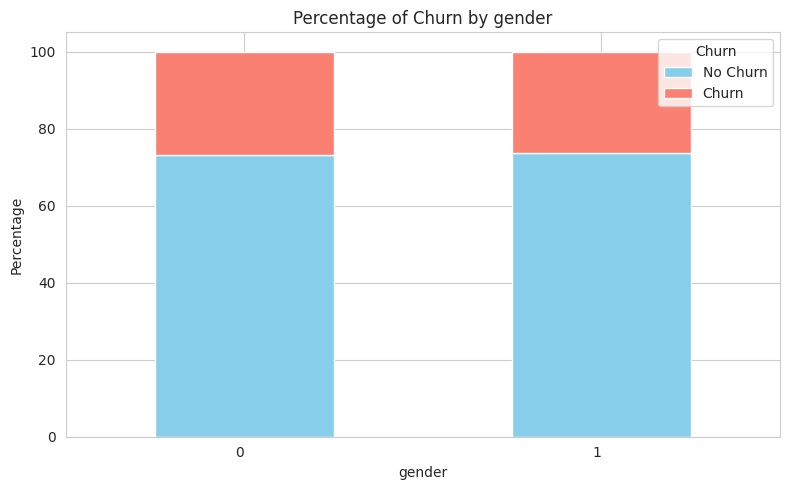

<Figure size 800x500 with 0 Axes>

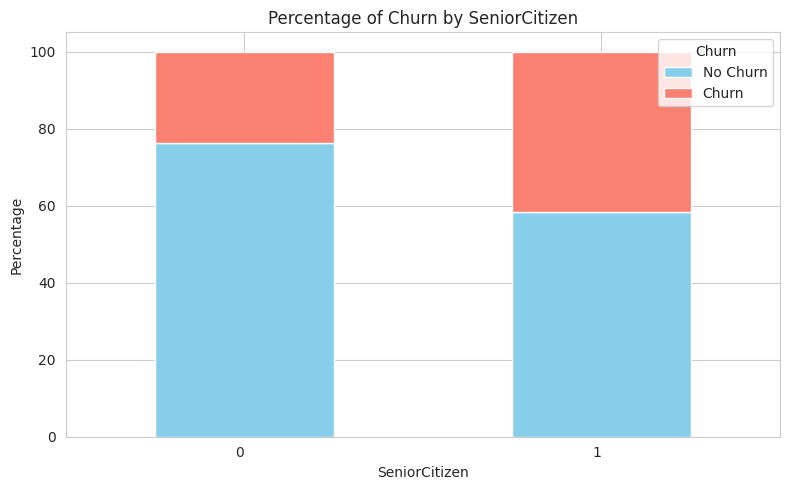

<Figure size 800x500 with 0 Axes>

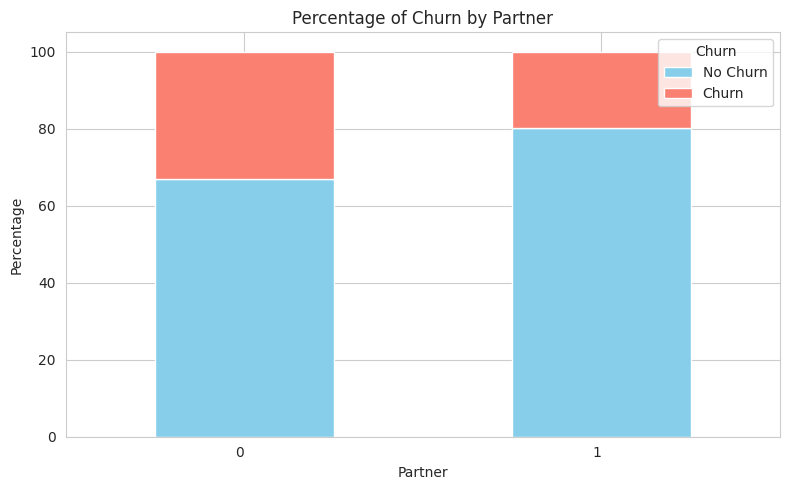

<Figure size 800x500 with 0 Axes>

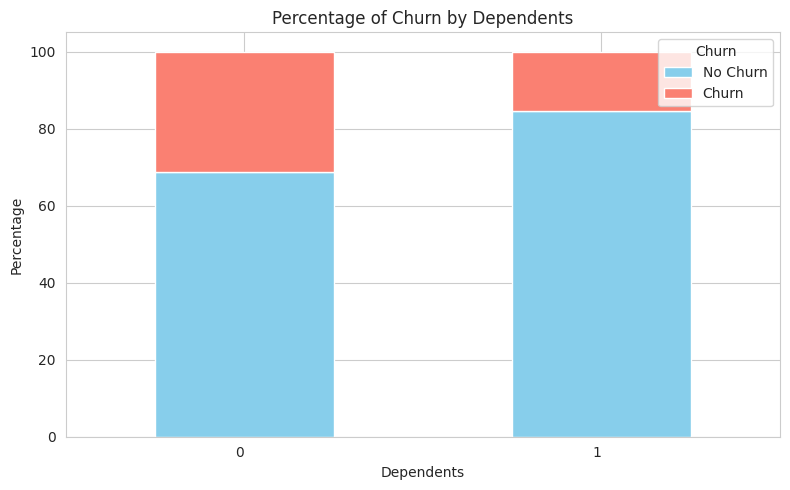

<Figure size 800x500 with 0 Axes>

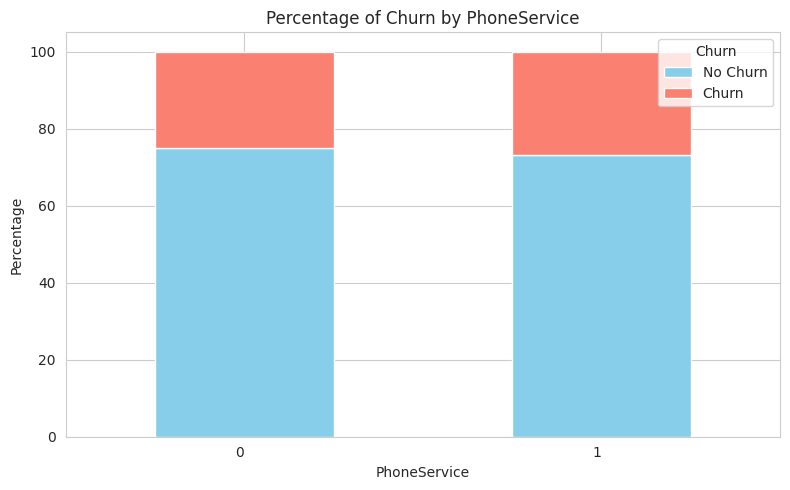

<Figure size 800x500 with 0 Axes>

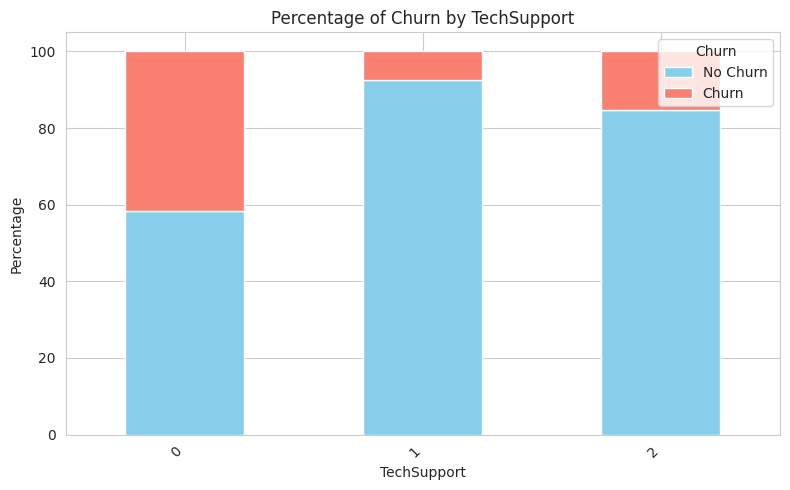

<Figure size 800x500 with 0 Axes>

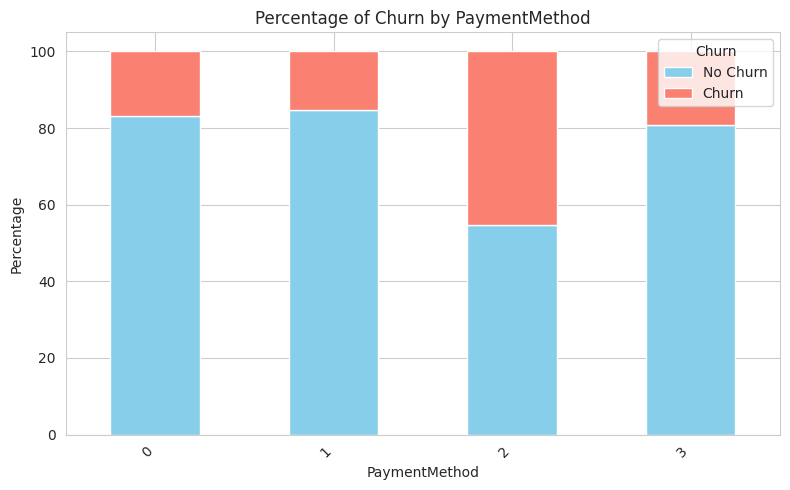

In [ ]:
for col in columns_to_plot:
  # Plotting percentage of churn
    plt.figure(figsize=(8, 5))
    (df.groupby(col)['Churn'].value_counts(normalize=True).mul(100).unstack().plot(kind='bar', stacked=True, figsize=(8, 5), color=['skyblue', 'salmon']))
    plt.title(f'Percentage of Churn by {col}')
    plt.xlabel(col)
    plt.ylabel('Percentage')
    plt.xticks(rotation=0 if df[col].nunique() <= 2 else 45, ha='right')
    plt.legend(title='Churn', labels=['No Churn', 'Churn'], loc='upper right')
    plt.tight_layout()
    plt.show()